In [28]:
import torch
from torchvision.transforms.v2 import RandomHorizontalFlip as rhflip, RandomVerticalFlip as rvflip
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda


In [29]:
dataset = "samson"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

Y_init_f = rsfm.reshape_Y("DOFA", Y_init, None)

features: torch.Size([1024, 196])


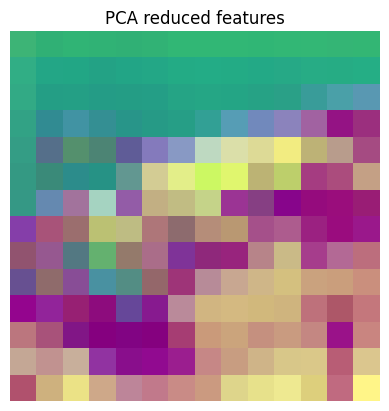

In [30]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="large", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths)#, patch_size=112)

D = int(features.shape[0])
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")
plots.plot_pca_features(features)

In [31]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H

        # Upsampling features
        self.upsample = nn.Linear(self.alpha**2, self.H**2, bias=False)
        
        # Upsampled features to abundances
        # self.abundance_estimator = unmx.Abundance_estimator(self.D, self.c, n_features=1)


        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(in_channels=D, out_channels=128, kernel_size=1, stride=1, padding=0),
            nn.GroupNorm(4, 128),
            nn.SiLU(),
            nn.Conv2d(in_channels=128, out_channels=c, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(c),
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(c, B)

        # K = 50
        # # self.e_sequences = nn.Embedding(B, K*c)
        # # self.weights = nn.Parameter(torch.ones((K, c)))
        # self.num_queries = K * c
        # self.query_embed = nn.Embedding(self.num_queries, B)
        # self.weights = nn.Parameter(torch.ones((c, K)))
        # self._reset_parameters()

    def _reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.GroupNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform(m.weight)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_mse=0.09, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        mse = nn.MSELoss(reduction='sum')
        mse2 = nn.MSELoss()
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Abundances and endmembers regularisation"""

        # TV on endmembers (sum of difference between consecutive endmembers)
        loss_tv_e = W_tv_e * (torch.abs(E_hat[:, 1:] - E_hat[:, :-1]).sum())

        # Endmember regul : distance to mean spectrum
        B, c = E_hat.shape
        # mean_e = Y_gt.mean(dim=(2,3)).flatten(0).repeat(c).reshape(B, c)
        E_mean = torch.mean(Y_hat, dim=(2,3)).repeat(1, c).reshape(-1, c)
        # print(E_hat.shape, E_mean.shape)
        loss_e = 0 #mse2(E_mean, E_hat)
        # loss_a = W_a * torch.norm(A_hat, p=0.5, dim=1).mean()

        loss = loss_sad + loss_ab + loss_tv_e + loss_mse + loss_e

        if return_losses:
            return loss, loss_sad, loss_ab, loss_tv_e, loss_mse
        else:
           return loss

    # @staticmethod
    # def loss(y_true, y_pred, endm, hsi_mean, pred_aban):
    #     weight_mse, weight_sad, weight_endm, weight_aban = 1, 1, 1, 1e-2
    #     mse = nn.MSELoss()
    #     sad = losses.SADLoss()

    #     loss = 0
    #     loss += weight_mse * mse(y_true, y_pred)

    #     y_true = y_true.view(y_true.shape[0], y_true.shape[1], -1).transpose(1, 2)
    #     y_pred = y_pred.reshape(y_pred.shape[0], y_pred.shape[1], -1).transpose(1, 2)

    #     loss += 1e-4 *(torch.abs(endm[:, 1:] - endm[:, :-1]).sum())

    #     loss += weight_sad * sad(y_true, y_pred)
    #     loss += weight_endm * mse(hsi_mean, endm)
    #     aban_norm = torch.norm(pred_aban, p=0.5, dim=1)
    #     loss += weight_aban * aban_norm.mean()
    #     return loss

    def get_abundances(self, features):
        features_up = self.upsample(features)
        features_up = features_up.view(
            1, self.D, self.H, self.H
        )
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmember(self):
        # query_embed_weight_split = torch.chunk(self.query_embed.weight, self.c, dim=0)
        # query_embed_weight_split = torch.stack(query_embed_weight_split)
        # endmember_get = self.weights.unsqueeze(-1).repeat(1, 1, self.B) * query_embed_weight_split
        # endmember_get = torch.mean(endmember_get, dim=1)
        # query_embed_weight_split = torch.chunk(self.e_sequences.weight, self.c, dim=0)
        # query_embed_weight_split = torch.stack(query_embed_weight_split)
        # print(query_embed_weight_split.shape, self.weights.shape)
        # endmember_get = self.weights.unsqueeze(-1).repeat(1, 1, self.B) * query_embed_weight_split
        # endmember_get = torch.mean(endmember_get, dim=1)
        # return endmember_get        
        return self.decoder.get_endmembers()
    
    def forward(self, features):
        A_hat = self.get_abundances(features)
        E_hat = self.get_endmember()
        Y_hat = torch.einsum('brhw,lr->blhw', [A_hat, E_hat])

        return E_hat, A_hat, Y_hat

training 1/2


100%|██████████| 1000/1000 [01:30<00:00, 11.07it/s]


Current SAD = 0.055, NMSE = 0.224
training 2/2


100%|██████████| 1000/1000 [01:30<00:00, 11.07it/s]


Current SAD = 0.055, NMSE = 0.222
Model has 9.966813M params
Average SAD = 0.0555 ± 0.000, NMSE = 0.2231 ± 0.001


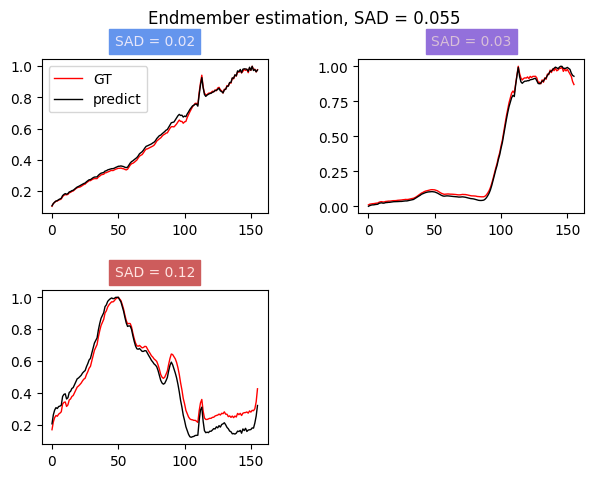

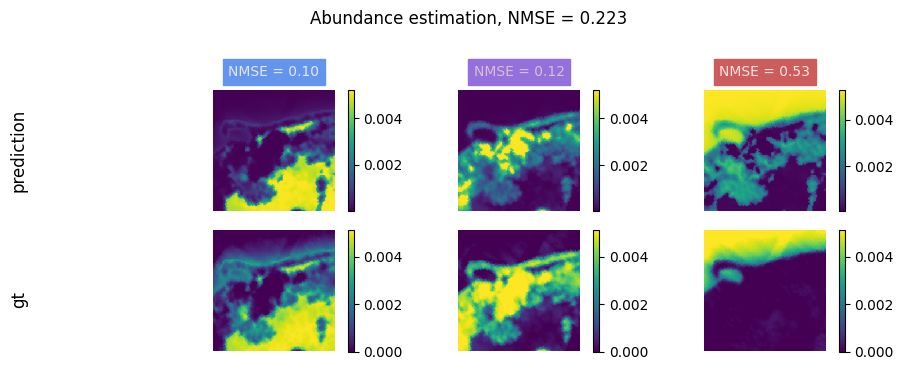

In [ ]:
"""Linear upsampling of feature"""

n_xp = 2
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
E_mean = torch.mean(Y_init, dim=(2,3)).repeat(1, c).reshape(c, -1)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D, alpha=alpha, H=new_H, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True)

    # epochs, lr = 200, 0.002
    epochs, lr = 1000, 3e-3
    # optim_wrapper = dict(
    #     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    #     constructor='LayerDecayOptimizerConstructor_ViT',
    #     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    # optimizer = build_optim_wrapper(model, optim_wrapper)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=45, gamma=0.9)

    for _ in tqdm(range(epochs)):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)

            E_hat, A_hat, Y_hat = model(features)

            # loss = model.loss(Y_fm, Y_hat, E_hat, E_mean, A_hat)
            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat.T)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)

            # for p in model.query_embed.weight:
            #     p.data.clamp_(1e-7, 1)

            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
        scheduler.step()
    model.eval()
    
    with torch.no_grad():
        
        _, features = rsfm.extract_f(fm, Y, new_H, wavelengths)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(features)
        # E_hat = E_hat.T
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")